## INTERNSHIP OFFER ACCEPTANCE PROJECT

## Problem statement


Organizations often face uncertainty  as candidates may reject offers due to multiple factors such as compensation mismatch, location constraints, or exam time

The objective of this project is to predict the probability that a candidate will accept a internship  offer and to analyze the key factors influencing the decision using interpretable machine learning models.



In [104]:
import numpy as np
import pandas as pd

In [105]:
np.random.seed(42)
n = 1000


In [106]:
stipend = np.random.randint(1000,30001,n)
duration =np.random.randint(1,7,n)
wfh =np.random.choice([1,0],n,p=[0.6,0.4])
distance = np.where(
    wfh == 1,0,np.random.randint(1,35,n)
)

exam_time=np.random.choice([1,0],n,p=[0.7,0.3])

acceptance_probability = (
    0.4 * (stipend / 30000) +        # higher stipend → higher acceptance
    0.3 * wfh +                      # WFH increases acceptance
    0.2 * (1 - distance / 1500) -    # farther distance reduces acceptance
    0.3 * exam_time                  # exams reduce acceptance
)

# Ensure probability is between 0 and 1
acceptance_probability = np.clip(acceptance_probability, 0, 1)

accepted =np.random.binomial(1,acceptance_probability)

In [107]:
df =pd.DataFrame(
    {
        "stipend":stipend,
        "duration":duration,
        "wfh":wfh,
        "distance":distance,
        "exam_time":exam_time,
        "accepted":accepted 
        
        
    }
)

In [108]:
kf =df.copy()

In [109]:
df.sample(4)

,stipend,duration,wfh,distance,exam_time,accepted
330,10208,5,0,14,1,0
576,24788,2,1,0,0,1
120,17216,3,1,0,0,1
439,20554,6,1,0,1,1


In [110]:
df.shape

(1000, 6)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   stipend    1000 non-null   int32
 1   duration   1000 non-null   int32
 2   wfh        1000 non-null   int64
 3   distance   1000 non-null   int32
 4   exam_time  1000 non-null   int64
 5   accepted   1000 non-null   int32
dtypes: int32(4), int64(2)
memory usage: 31.4 KB


In [112]:
df.describe()

,stipend,duration,wfh,distance,exam_time,accepted
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,15784.057000,3.474000,0.603000,6.836000,0.696000,0.388000
std,8527.878948,1.721711,0.489521,10.377032,0.460213,0.487538
min,1009.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,8207.500000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,15594.000000,3.000000,1.000000,0.000000,1.000000,0.000000
75%,23367.250000,5.000000,1.000000,13.000000,1.000000,1.000000
max,29940.000000,6.000000,1.000000,34.000000,1.000000,1.000000


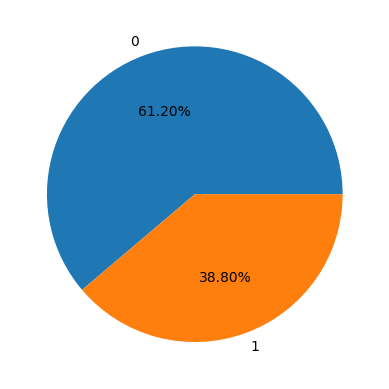

In [113]:
import seaborn as sns 
import  matplotlib.pyplot as plt
df["accepted"].value_counts().plot(
    kind="pie",
    autopct="%.2f%%"
)
plt.ylabel("") 
plt.show()


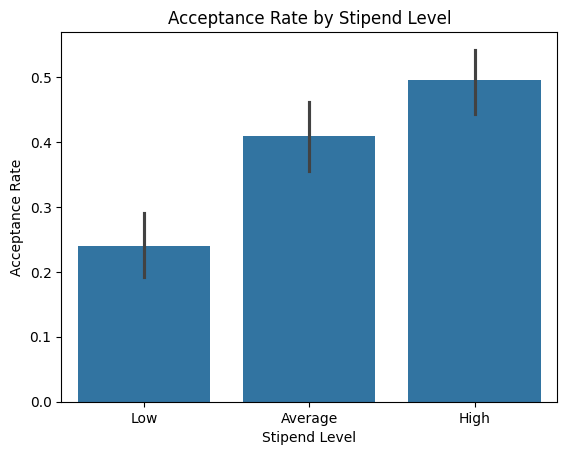

In [114]:
df["stipend2"] = pd.cut(
    df["stipend"],
    bins=[1000,10000,20000, 30000],
    labels=["Low", "Average", "High"]
)

sns.barplot(
    data=df,
    x="stipend2",
    y="accepted"
)

plt.title("Acceptance Rate by Stipend Level")
plt.xlabel("Stipend Level")
plt.ylabel("Acceptance Rate")
plt.show()

<Axes: xlabel='wfh', ylabel='accepted'>

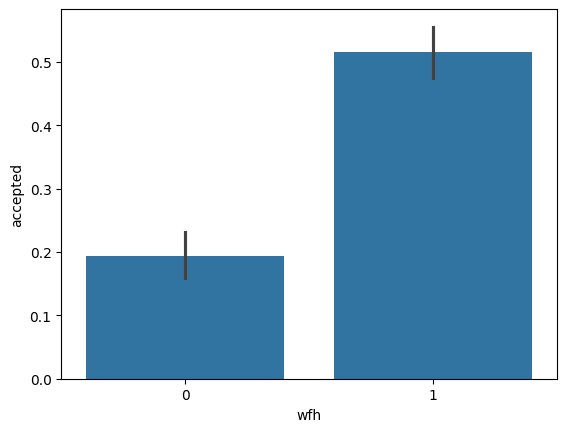

In [115]:
sns.barplot(
    data=df,
    x="wfh",
    y="accepted"
)

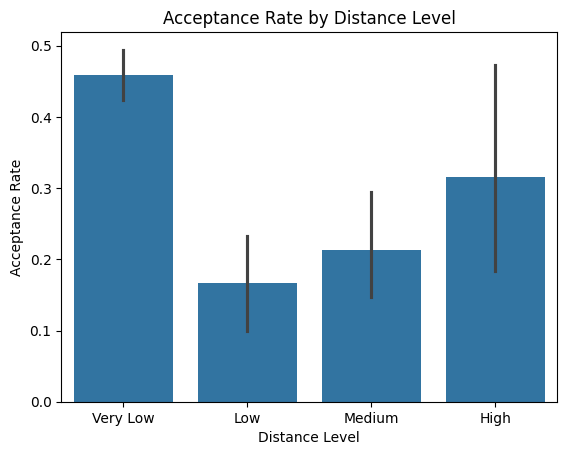

In [116]:
df["distance_level"] = pd.cut(
    df["distance"],
    bins=[-1, 10, 20, 30, 35],
    labels=["Very Low", "Low", "Medium", "High"]
)
sns.barplot(
    data=df,
    x="distance_level",
    y="accepted"
)

plt.title("Acceptance Rate by Distance Level")
plt.xlabel("Distance Level")
plt.ylabel("Acceptance Rate")
plt.show()


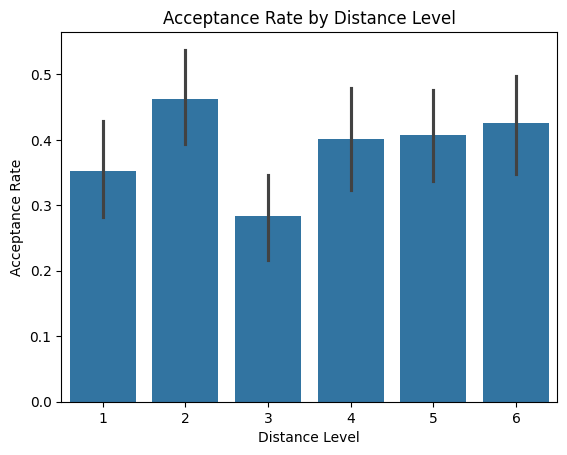

In [117]:
df["duration_level"] = pd.cut(
    df["duration"],
    bins=[0,1,2,3,4,5,7],
    labels=["1","2","3","4","5","6"]
)
sns.barplot(
    data=df,
    x="duration_level",
    y="accepted"
)

plt.title("Acceptance Rate by Distance Level")
plt.xlabel("Distance Level")
plt.ylabel("Acceptance Rate")
plt.show()


<Axes: xlabel='exam_time', ylabel='accepted'>

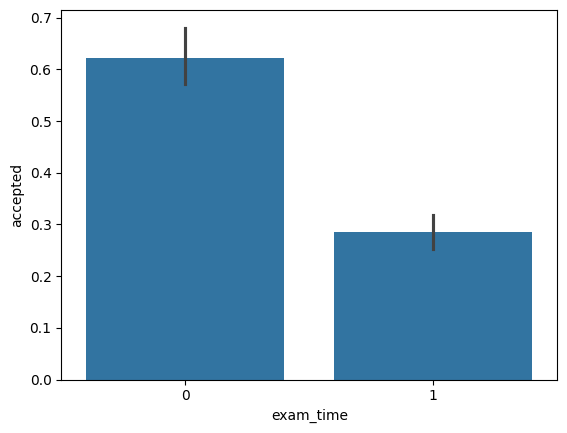

In [118]:
sns.barplot(
    data=df,
    x="exam_time",
    y="accepted"
)


Exploratory Data Analysis (EDA) – Key Insights
1. Target Variable Distribution (Offer Acceptance)

Approximately 63% of internship offers are rejected, while 37% are accepted.

This indicates that students are selective in accepting offers, making acceptance prediction a meaningful classification problem.

The class distribution is moderately imbalanced but suitable for Logistic Regression and KNN.

2. Stipend vs Acceptance

Acceptance rate increases with higher stipend ranges.

Students are more likely to accept offers that provide better financial compensation.

This confirms stipend as a strong positive predictor of acceptance.

3. Work From Home (WFH) Impact

WFH internships have a significantly higher acceptance rate compared to on-site roles.

Flexibility and elimination of relocation/travel constraints strongly influence student decisions.

WFH emerges as a high-impact binary feature.

4. Distance vs Acceptance

Acceptance rate is highest for very low distances and consistently decreases as distance increases.

Offers requiring longer travel or relocation are more likely to be rejected.

Distance acts as a strong negative factor, especially for on-site roles.

5. Exam Time vs Acceptance

Offers made outside exam periods show higher acceptance rates.

During exam time, students prioritize academics, leading to increased rejections.

Academic timing is a contextual constraint influencing decisions.

6.Duration vs Acceptance

for 2 month duration the acceptance rate is high as compared to other 

## Overall Behavioral Insight

Internship acceptance decisions are influenced by a combination of financial, logistical, and academic factors.

No single feature determines acceptance; rather, decisions emerge from feature interactions (e.g., WFH reduces the impact of distance).

The observed trends align with real-world student behavior, validating the dataset’s realism.

## FEATURE ENGINEERING

In [119]:

kf

,stipend,duration,wfh,distance,exam_time,accepted
0,24654,1,0,19,1,0
1,16795,1,1,0,0,1
2,1860,5,1,0,1,1
3,6390,5,0,30,0,0
4,22575,6,0,9,1,0
...,...,...,...,...,...,...
995,9427,5,0,28,1,0
996,9580,5,0,21,0,0
997,28613,3,0,7,1,0
998,25285,4,1,0,1,1


In [120]:
X = df[["stipend", "duration", "distance", "wfh", "exam_time"]]
y = df["accepted"]


In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["stipend", "distance", "duration"]
bin_cols = ["wfh", "exam_time"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("bin", "passthrough", bin_cols)
    ]
)


In [123]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])


In [124]:
pipeline.fit(X_train, y_train)
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.70      0.75       122
           1       0.61      0.72      0.66        78

    accuracy                           0.71       200
   macro avg       0.70      0.71      0.70       200
weighted avg       0.72      0.71      0.71       200



In [125]:
import pickle

with open("offer.pkl", "wb") as f:
    pickle.dump(pipeline, f)
